In [110]:
from keras.src.saving import load_model
from keras.src.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import glob
import cv2
import os

In [111]:
warnings.filterwarnings('ignore')

VERSION = "v25"
BASE_DIR = "output"
DATASET_DIR = "dataset"
TRAIN_PATH = os.path.join(DATASET_DIR, "training")

IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32

TOTAL_SIZE = 4000
TRAIN_SIZE = 3200
VAL_SIZE = 400
TEST_SIZE = 400

CLASS_NAMES = sorted([os.path.basename(d) for d in glob.glob(os.path.join(TRAIN_PATH, "*")) if os.path.isdir(d)])
LABEL_MAPPING = {class_name: idx for idx, class_name in enumerate(CLASS_NAMES)}
NB_CLASSES = len(CLASS_NAMES)

In [112]:
def load_data(dataset, label_mapping, image_size=IMAGE_SIZE):
    images, labels = [], []
    for folder in os.listdir(dataset):
        folder_path = os.path.join(dataset, folder)
        if folder not in label_mapping or not os.path.isdir(folder_path):
            continue

        label = label_mapping[folder]
        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)
            image = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, image_size)
            images.append(image)
            labels.append(label)
    return np.array(images, dtype='float32'), np.array(labels, dtype='int')

In [113]:
images, labels = load_data(TRAIN_PATH, LABEL_MAPPING)
images, labels = shuffle(images, labels, random_state=42)

In [114]:
train_images, temp_images, train_labels, temp_labels = train_test_split(
    images, labels, stratify=labels, test_size=(VAL_SIZE + TEST_SIZE) / TOTAL_SIZE, random_state=42
)
val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images, temp_labels, stratify=temp_labels, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE), random_state=42
)

In [115]:
test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow(test_images, test_labels, batch_size=BATCH_SIZE, shuffle=False, seed=42)

In [116]:
test_labels = to_categorical(test_labels, num_classes=NB_CLASSES)

In [117]:
# Load the model
model = load_model("output/model/v26/train_fine_tuned.keras")

In [118]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,988,142 (263.17 MB)

 Trainable params: 22,983,972 (87.68 MB)

 Non-trainable params: 36,224 (141.50 KB)

 Optimizer params: 45,967,946 (175.35 MB)

In [119]:
# Confusion matrix 
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=45)
    plt.show()

In [120]:
# Evaluate the model
print("Evaluating on Test Set...")
test_loss, test_acc, test_prec, test_rec = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc}, Precision: {test_prec}, Recall: {test_rec}")

Evaluating on Test Set...


ValueError: Arguments `target` and `output` must have the same rank (ndim). Received: target.shape=(None,), output.shape=(None, 4)

13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step

📊 Classification Report (dict):
{'alcohol': {'precision': 0.9900990099009901, 'recall': 1.0, 'f1-score': 0.9950248756218906, 'support': 100.0}, 'blood': {'precision': 1.0, 'recall': 0.99, 'f1-score': 0.9949748743718593, 'support': 100.0}, 'sexual': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 100.0}, 'traffic_accident': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 100.0}, 'accuracy': 0.9975, 'macro avg': {'precision': 0.9975247524752475, 'recall': 0.9975, 'f1-score': 0.9974999374984375, 'support': 400.0}, 'weighted avg': {'precision': 0.9975247524752475, 'recall': 0.9975, 'f1-score': 0.9974999374984376, 'support': 400.0}}


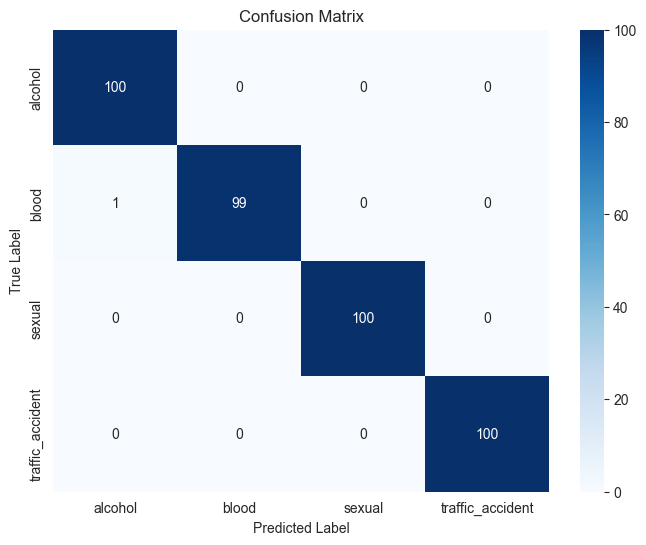

In [107]:
# Make predictions
predictions = model.predict(test_generator)
pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(test_labels, axis=1)

# Classification Report
class_report = classification_report(true_labels, pred_labels, target_names=CLASS_NAMES, output_dict=True)
print(f"\n📊 Classification Report (dict):\n{class_report}")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Predictions (all): [[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 ...
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]
Image index 345:
  True label: alcohol
  Predicted label: blood
  Prediction probabilities: [0. 1. 0. 0.]
  Confidence: 1.00
Image index 358:
  True label: blood
  Predicted label: blood
  Prediction probabilities: [0. 1. 0. 0.]
  Confidence: 1.00
Image index 370:
  True label: blood
  Predicted label: blood
  Prediction probabilities: [0. 1. 0. 0.]
  Confidence: 1.00
Image index 59:
  True label: traffic_accident
  Predicted label: blood
  Prediction probabilities: [0. 1. 0. 0.]
  Confidence: 1.00
Image index 121:
  True label: sexual
  Predicted label: blood
  Prediction probabilities: [0. 1. 0. 0.]
  Confidence: 1.00
Image index 252:
  True label: blood
  Predicted label: blood
  Prediction probabilities: [0. 1. 0. 0.]
  Confidence: 1.00
Image index 145:
  True label: blood
  Predicted label: blood
  Prediction probabilities: [0. 1. 0. 0.]
  Confidence: 1.00
Image index

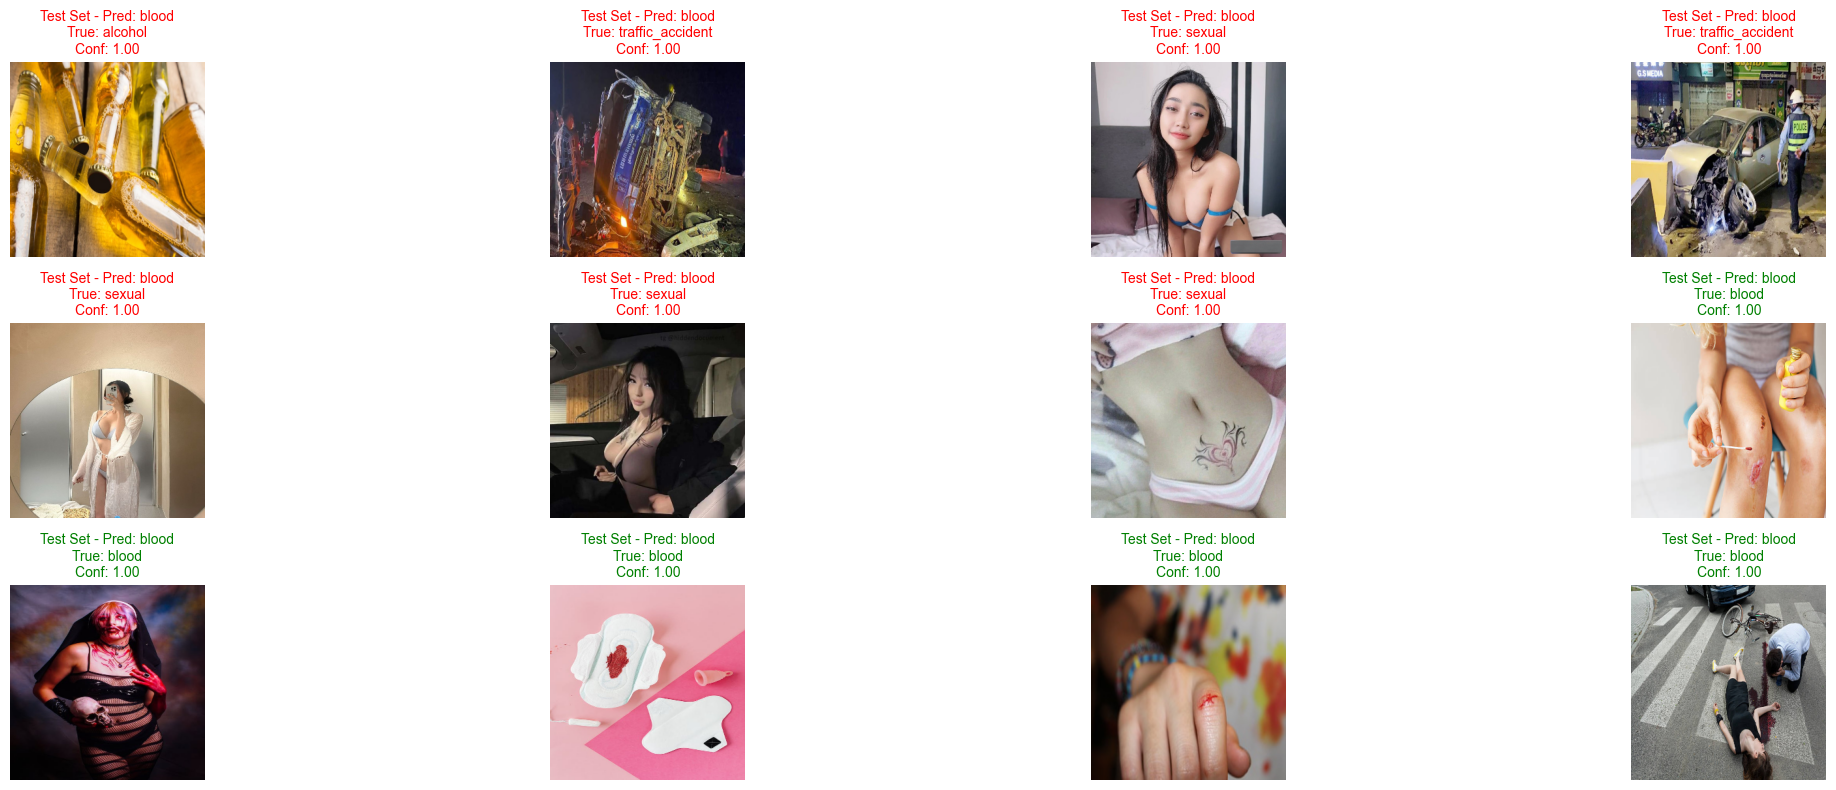

In [108]:
def display_sample_predictions(model, class_names, images, labels, set_name="Sample", num_images=12,
                               confidence_threshold=0.9):
    num_images = min(num_images, len(images))
    random_indices = np.random.choice(len(images), num_images, replace=False)

    plt.figure(figsize=(num_images * 2, 8))

    misclassified = []
    correct = []

    # Get all predictions at once for efficiency
    predictions = model.predict(images, verbose=0)

    print("Predictions (all):", predictions)  # Print all predictions for debugging

    for idx in random_indices:
        # Get the true label and model prediction
        true_label = np.argmax(labels[idx])
        prediction = predictions[idx]
        predicted_label = np.argmax(prediction)
        confidence = np.max(prediction)

        # Print confidence and other details for each sample
        print(f"Image index {idx}:")
        print(f"  True label: {class_names[true_label]}")
        print(f"  Predicted label: {class_names[predicted_label]}")
        print(f"  Prediction probabilities: {prediction}")
        print(f"  Confidence: {confidence:.2f}")

        if confidence >= confidence_threshold:
            if predicted_label == true_label:
                correct.append((idx, confidence))
            else:
                misclassified.append((idx, confidence))

    # Sorting misclassified and correct samples by confidence
    sorted_indices = [i[0] for i in sorted(misclassified + correct, key=lambda x: x[1], reverse=True)]

    cols = min(num_images, 4)
    rows = (num_images + cols - 1) // cols

    # Display the images and their details
    for i, idx in enumerate(sorted_indices[:num_images]):
        image = images[idx]
        true_label = np.argmax(labels[idx])
        prediction = predictions[idx]
        predicted_label = np.argmax(prediction)
        confidence = np.max(prediction)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image.astype(np.uint8))
        plt.axis('off')

        title_color = "green" if predicted_label == true_label else "red"
        plt.title(f"{set_name} Set - Pred: {class_names[predicted_label]}\n"
                  f"True: {class_names[true_label]}\n"
                  f"Conf: {confidence:.2f}",
                  fontsize=10, color=title_color)

    plt.tight_layout()
    plt.show()


display_sample_predictions(model, CLASS_NAMES, test_images, test_labels, set_name="Test")

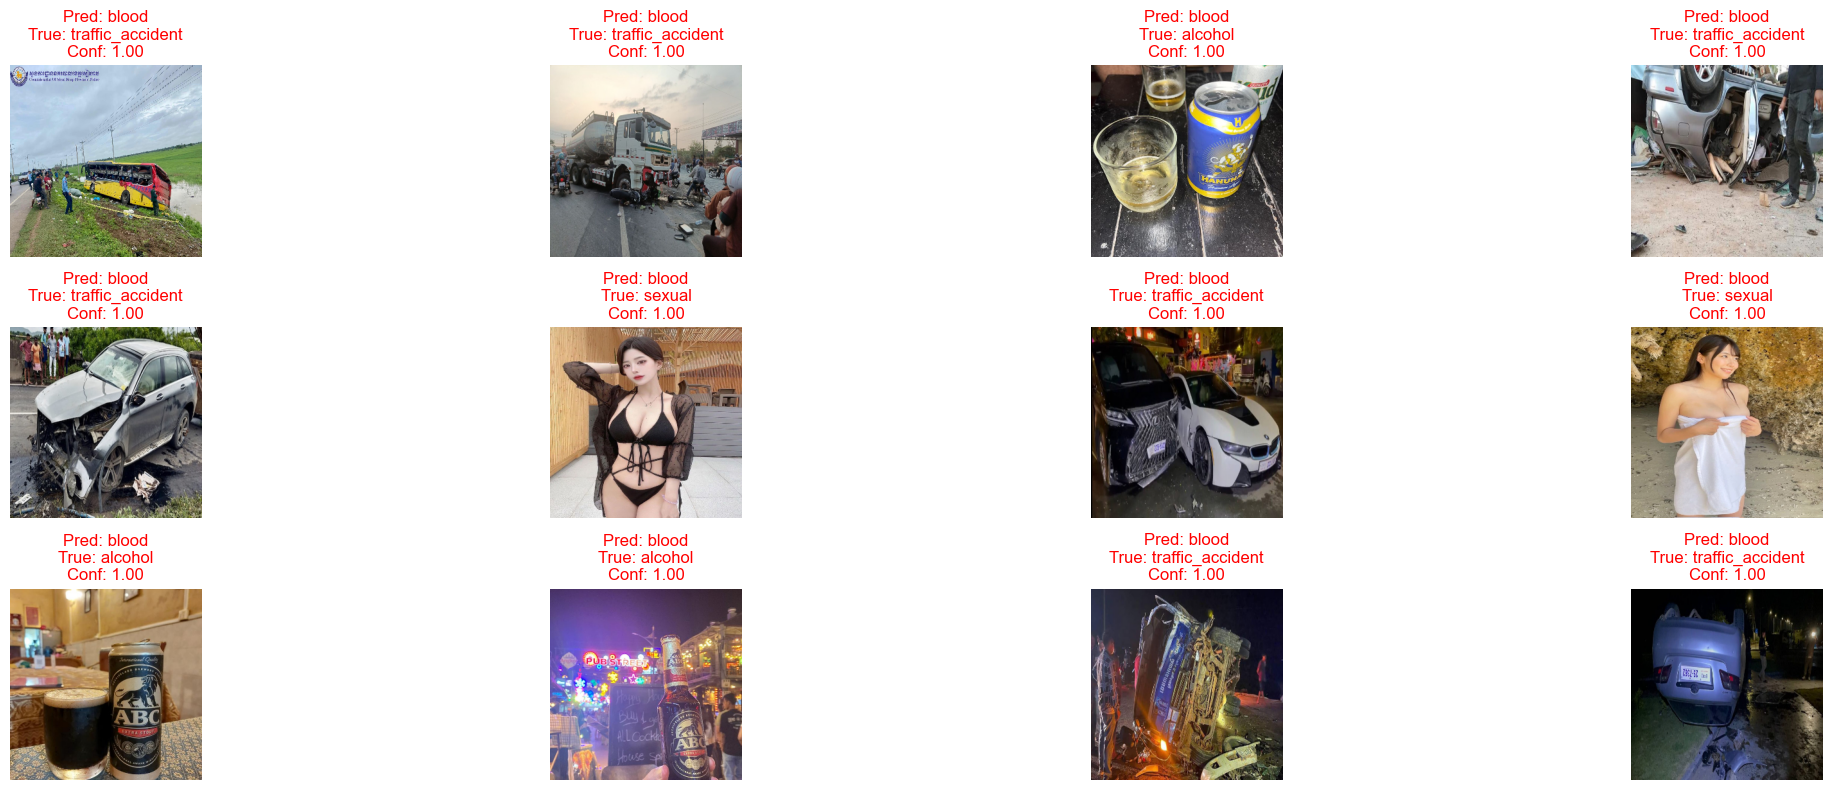

In [109]:
def display_misclassifications(model, class_names, images, labels, num_images=12):
    y_pred = np.argmax(model.predict(images, verbose=0), axis=1)
    y_true = np.argmax(labels, axis=1)
    misclassified_indices = np.where(y_pred != y_true)[0]
    if len(misclassified_indices) == 0:
        print("No misclassifications found!")
        return
    random_indices = np.random.choice(misclassified_indices, min(num_images, len(misclassified_indices)), replace=False)
    plt.figure(figsize=(num_images * 2, 8))
    for i, idx in enumerate(random_indices[:num_images]):
        image = images[idx]
        true_label = y_true[idx]
        pred_label = y_pred[idx]
        confidence = np.max(model.predict(np.expand_dims(image, axis=0), verbose=0))
        plt.subplot(3, 4, i + 1)
        plt.imshow(image.astype(np.uint8))
        plt.axis('off')
        plt.title(f"Pred: {class_names[pred_label]}\nTrue: {class_names[true_label]}\nConf: {confidence:.2f}",
                  color='red')
    plt.tight_layout()
    plt.show()


display_misclassifications(model, CLASS_NAMES, test_images, test_labels)